# Clasificación Multiclase: Softmax y Entropía Cruzada

**Análisis y procesamiento de Señales** - Bioingeniería - Fac. de Ingeniería - UNSTA - 2026

En la primera parte de la clase vimos cómo entrenar un clasificador binario (2 clases) minimizando el error SSE. Sin embargo, en problemas reales solemos tener **múltiples categorías** (como las 3 especies del dataset Iris).

En esta notebook vamos a implementar un clasificador multiclase siguiendo los conceptos de la clase:

1. **One-Hot Encoding** para representar las etiquetas.
2. Función de activación **Softmax** para obtener probabilidades.
3. Función de costo **Entropía Cruzada Categórica**.
4. Implementación desde cero y con **TensorFlow**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## 1. Carga de datos y One-Hot Encoding

Utilizaremos las 3 especies de Iris y 2 características para poder visualizar las fronteras de decisión en un plano.

In [2]:
iris = sns.load_dataset("iris")

# Usamos largo y ancho de pétalo
X = iris[["petal_length", "petal_width"]].values

# Mapeamos nombres de especies a enteros
class_mapping = {species: i for i, species in enumerate(iris["species"].unique())}
y_int = iris["species"].map(class_mapping).values

# One-Hot Encoding manual
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

D = one_hot_encode(y_int, 3)

print(f"X shape: {X.shape}")
print(f"Etiquetas One-Hot (primeras 5):\n{D[:5]}")

X shape: (150, 2)
Etiquetas One-Hot (primeras 5):
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


## 2. Implementación desde Cero

Para un clasificador multiclase, necesitamos una neurona de salida por cada clase. La salida de cada neurona pasa por una función **Softmax** para asegurar que sumen 1 y sean positivas.

In [3]:
class MulticlassPerceptron:
    def __init__(self, n_inputs, n_outputs, eta=0.1, max_epochs=500, seed=42):
        rng = np.random.default_rng(seed)
        # Matriz de pesos: (inputs + 1) x outputs
        self.W = rng.uniform(-1, 1, size=(n_inputs + 1, n_outputs))
        self.eta = eta
        self.max_epochs = max_epochs
        self.history = {"loss": [], "acc": []}

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def _softmax(self, z):
        # Restamos el max para estabilidad numérica
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def predict_proba(self, X):
        Xb = self._add_bias(X)
        return self._softmax(Xb @ self.W)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def fit(self, X, D):
        Xb = self._add_bias(X)
        n_samples = len(X)
        
        for epoch in range(self.max_epochs):
            # Predicción
            Y = self._softmax(Xb @ self.W)
            
            # Cálculo del gradiente (Softmax + CrossEntropy)
            # Gradiente: X.T @ (Y - D) / n
            grad = (Xb.T @ (Y - D)) / n_samples
            
            # Actualización de pesos
            self.W -= self.eta * grad
            
            # Métricas
            loss = -np.mean(np.sum(D * np.log(Y + 1e-12), axis=1))
            acc = np.mean(np.argmax(Y, axis=1) == np.argmax(D, axis=1))
            
            self.history["loss"].append(loss)
            self.history["acc"].append(acc)

# Entrenamos el modelo
model_custom = MulticlassPerceptron(n_inputs=2, n_outputs=3, eta=0.2, max_epochs=1000)
model_custom.fit(X, D)

print(f"Precisión final (Custom): {model_custom.history['acc'][-1]*100:.2f}%")

Precisión final (Custom): 96.00%


### Visualización de Fronteras de Decisión

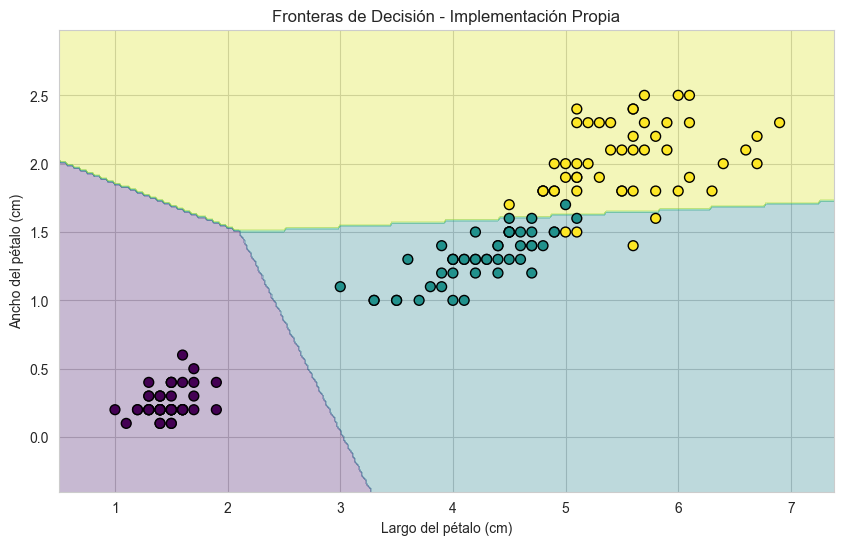

In [4]:
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), 
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    
    # Usamos colores directos para los puntos
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", cmap="viridis", s=50)
    plt.xlabel("Largo del pétalo (cm)")
    plt.ylabel("Ancho del pétalo (cm)")
    plt.title(title)
    plt.show()

plot_decision_boundaries(X, y_int, model_custom, "Fronteras de Decisión - Implementación Propia")

## 3. Implementación con TensorFlow

Ahora resolvemos el mismo problema usando la API de Keras. Para clasificación multiclase, usamos la pérdida `categorical_crossentropy`.

In [5]:
import tensorflow as tf

# Definimos el modelo
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='softmax', input_shape=(2,))
])

# Compilamos
model_tf.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2), 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])

# Entrenamos
history = model_tf.fit(X, D, epochs=1000, verbose=0)

print(f"Precisión final (TensorFlow): {history.history['accuracy'][-1]*100:.2f}%")

/Users/facundolucianna/Docencia/UNSTA/Procesamiento/Repo/signal-processing-bioengineering-unsta/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Precisión final (TensorFlow): 96.00%


### Comparación visual (TensorFlow)

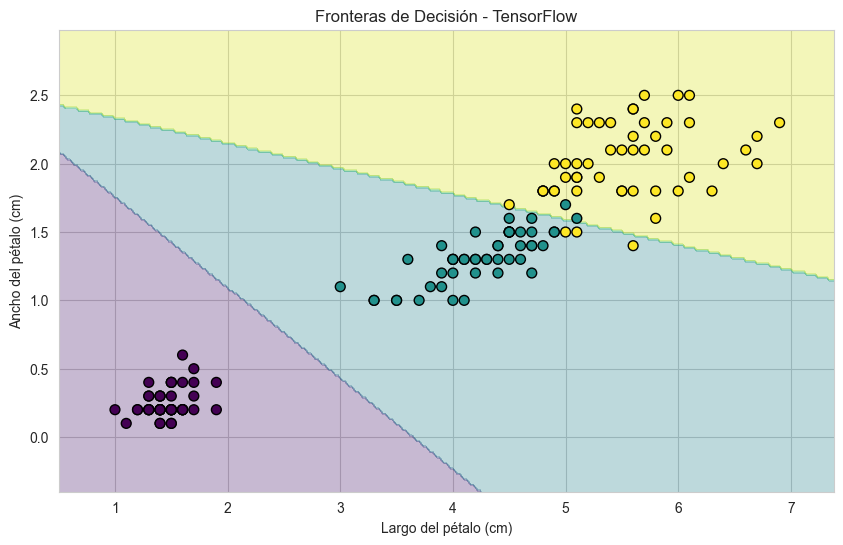

In [6]:
# Adaptamos el predict para la función de graficación
class TFModelWrapper:
    def __init__(self, tf_model):
        self.model = tf_model
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)

plot_decision_boundaries(X, y_int, TFModelWrapper(model_tf), "Fronteras de Decisión - TensorFlow")

## 4. Regularización L2 (Weight Decay)

Como se discutió en las slides (28-34), la regularización ayuda a evitar el sobreajuste penalizando pesos grandes. En TensorFlow, esto se añade fácilmente con `kernel_regularizer`.

In [7]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='softmax', 
                          kernel_regularizer=tf.keras.regularizers.l2(0.01), 
                          input_shape=(2,))
])

model_reg.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

model_reg.fit(X, D, epochs=500, verbose=0)

print("Modelo con regularización L2 entrenado.")

Modelo con regularización L2 entrenado.
